In [1]:
import json
from collections import Counter
from matplotlib import pyplot as plt

In [2]:
# merge 2 files Class_9_final.json and Class_10_final.json into one file called Class_9_10_final.json

with open('2-processed/mcqtimes.json', 'r') as f:
    mcq_times = json.load(f)

with open('2-processed/pakmcqs.json', 'r') as f:
    pak_mcqs = json.load(f)

with open('2-processed/native_mcqs.json', 'r') as f:
    mative_mcqs = json.load(f)

data = mcq_times + pak_mcqs + mative_mcqs

# if any question is duplicate in data, remove it (based on question text) and keep the first occurrence
seen_questions = set()

unique_data = []
for item in data:
    question = item['question']
    if question not in seen_questions:
        unique_data.append(item)
        seen_questions.add(question)

print(f"Total questions after merging: {len(data)}")
print(f"Total unique questions after merging: {len(unique_data)}")

Total questions after merging: 15137
Total unique questions after merging: 14482


In [3]:
data[0]

{'id': 0,
 'question': 'وے صورتیں الہی کس دیس بستیاں ہیں – اب دیکھنے کو جن کے آنکھیں ترستیاں ہیں – یہ کس شاعر کا شعر ہے؟',
 'options': {'A': 'میرتقی میر',
  'B': 'محمد رفیع سودا',
  'C': 'خواجہ حیدر بخش علی آتش',
  'D': 'مصحفی'},
 'domain': 'Humanities',
 'subdomain': 'urdu literature',
 'correct_option': 'محمد رفیع سودا',
 'correct_index': 1,
 'level': '',
 'source_url': 'https://mcqtimes.com/category/urdu/',
 'source': 'mcqtimes'}

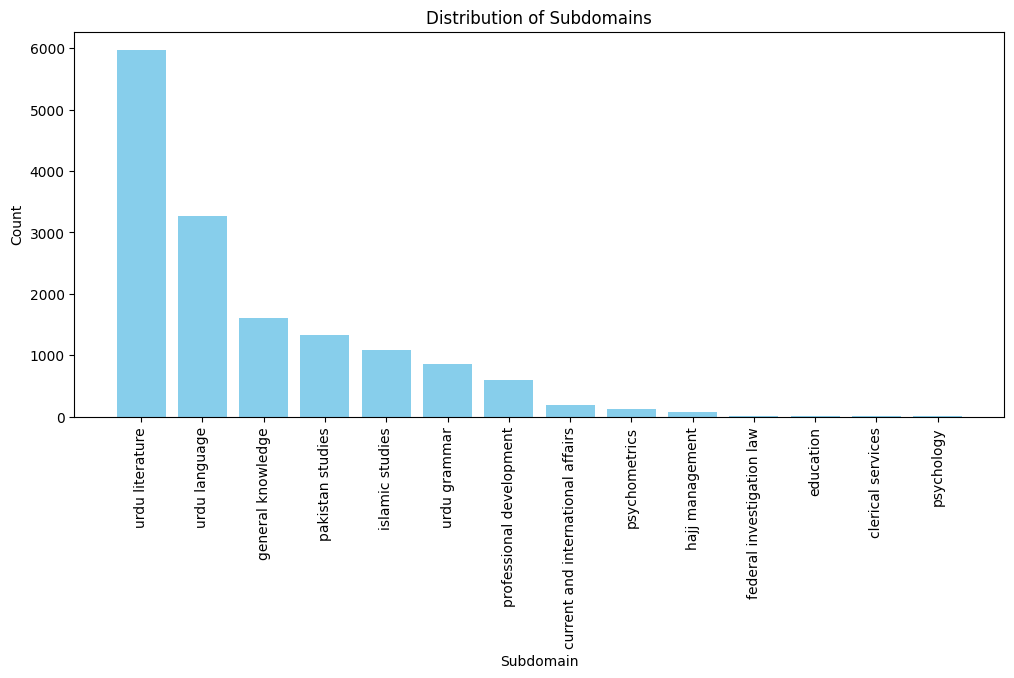

In [4]:
# len of unique subdomains
subdomains = [item['subdomain'] for item in data]
subdomain_counts = Counter(subdomains)
plt.figure(figsize=(12, 5))
# ascending order of subdomains based on count
subdomain_counts = dict(sorted(subdomain_counts.items(), key=lambda item: item[1],
                                    reverse=True))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='skyblue')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [5]:
# find sum of all counts in subdomain_counts
total_subdomain_count = sum(subdomain_counts.values())
print(f"Total questions in subdomains: {total_subdomain_count}")

Total questions in subdomains: 15137


In [6]:
# find unique value of key domain
domains = set([item['domain'] for item in data])
domains

{'Humanities', 'Other', 'Profession', 'Social Sciences'}

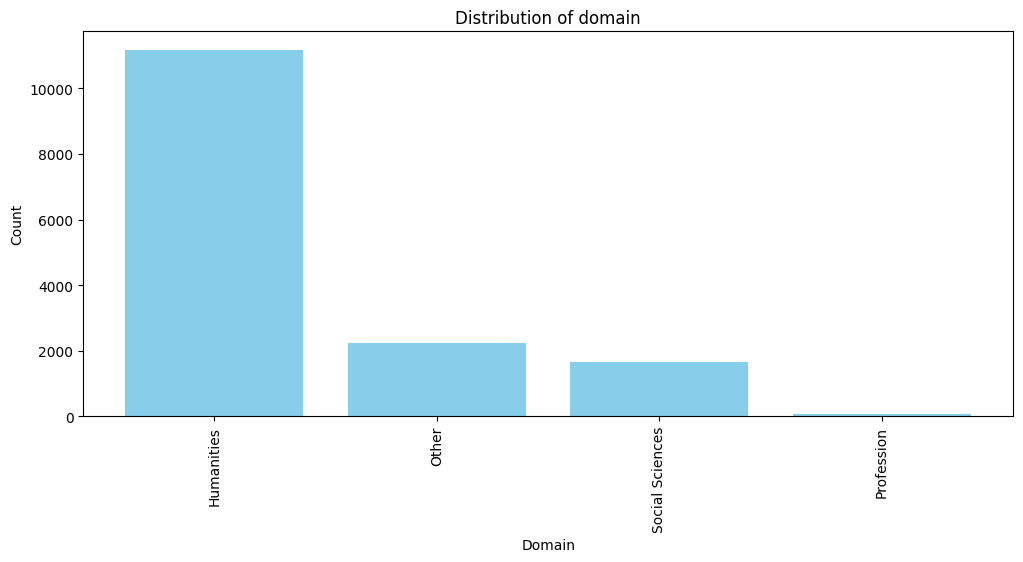

In [7]:
# len of unique domains
domain = [item['domain'] for item in data]
domain_counts = Counter(domain)
plt.figure(figsize=(12, 5))
# ascending order of subdomains based on count
domain_counts = dict(sorted(domain_counts.items(), key=lambda item: item[1],
                                    reverse=True))
plt.bar(domain_counts.keys(), domain_counts.values(), color='skyblue')
plt.title('Distribution of domain')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [8]:
domain_counts

{'Humanities': 11178, 'Other': 2225, 'Social Sciences': 1663, 'Profession': 71}

In [9]:
len(data)

15137

In [10]:
# start the id from 0 and make it incremental
for i, item in enumerate(data):
    item['id'] = i

In [11]:
# save the updated data in a new json file
with open('3-final/mcqs_with_answers.json', 'w') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)